# Explain the IDS model decisions

This optional stage explains **why** the trained Random Forests make their decisions. It uses three complementary methods:

1. **Built-in importance** — features used most often by the trees
2. **Permutation importance** — performance lost when one feature is shuffled
3. **SHAP** — how each feature pushes an individual prediction higher or lower

The notebook explains both binary intrusion detection and multiclass attack-type detection.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
RANDOM_STATE = 42

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_FILE = PROJECT_ROOT / 'artifacts/feature_selection/selected_features.json'
TEST_FILE = PROJECT_ROOT / 'dataset/processed/test.parquet'
BINARY_MODEL_FILE = PROJECT_ROOT / 'artifacts/models/random_forest.joblib'
ATTACK_MODEL_FILE = PROJECT_ROOT / 'artifacts/attack_type_model/random_forest_attack_type.joblib'

required_files = [FEATURE_FILE, TEST_FILE, BINARY_MODEL_FILE, ATTACK_MODEL_FILE]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

features = json.loads(FEATURE_FILE.read_text(encoding='utf-8'))['selected_features']
test = pd.read_parquet(TEST_FILE, columns=features + ['is_attack', 'attack_label'])
binary_model = joblib.load(BINARY_MODEL_FILE)
attack_model = joblib.load(ATTACK_MODEL_FILE)
binary_model.n_jobs = 1
attack_model.n_jobs = 1

print(f'SHAP version:          {shap.__version__}')
print(f'Test rows:             {len(test):,}')
print(f'Selected features:     {len(features)}')
print(f'Binary classes:        {list(binary_model.classes_)}')
print(f'Attack-type classes:   {len(attack_model.classes_)}')
assert binary_model.n_features_in_ == len(features)
assert attack_model.n_features_in_ == len(features)

SHAP version:          0.51.0
Test rows:             504,160
Selected features:     20
Binary classes:        [np.int8(0), np.int8(1)]
Attack-type classes:   14


## 1. Built-in Random Forest importance

This is fast and useful for an overview, but it can favor continuous or high-cardinality features. It should not be used alone.

Binary Random Forest: built-in feature importance


,importance
Average Packet Size,0.11160
Packet Length Variance,0.10262
Packet Length Std,0.08956
Bwd Packet Length Std,0.08702
Destination Port,0.07731
Packet Length Mean,0.07695
Bwd Packet Length Mean,0.05967
Max Packet Length,0.05379
Bwd Packet Length Max,0.05199
Fwd Packet Length Max,0.04396


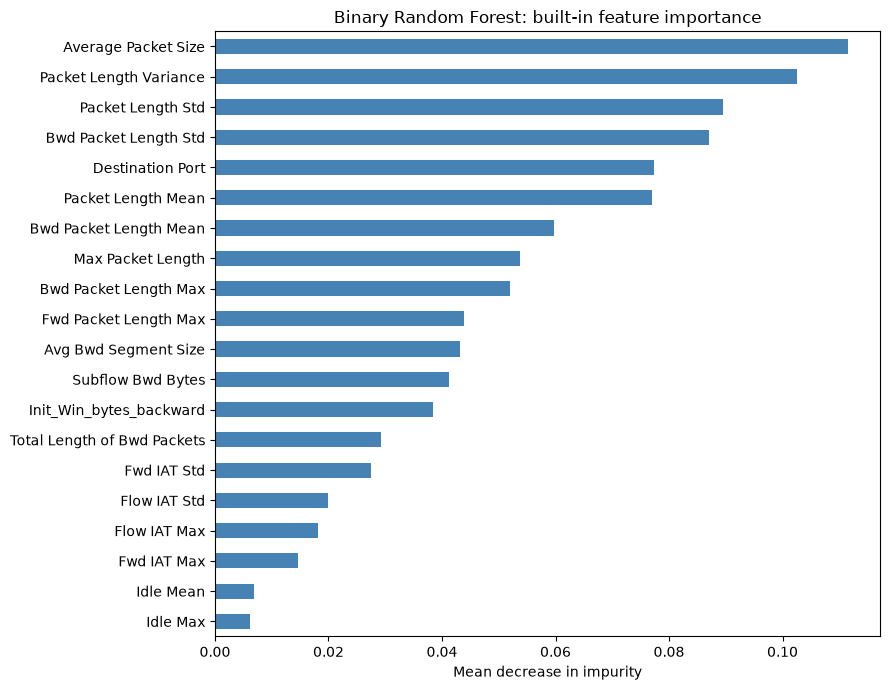

Attack-type Random Forest: built-in feature importance


,importance
Destination Port,0.11350
Init_Win_bytes_backward,0.10323
Fwd Packet Length Max,0.07311
Flow IAT Max,0.07051
Fwd IAT Max,0.06851
Flow IAT Std,0.06186
Fwd IAT Std,0.05509
Subflow Bwd Bytes,0.05045
Total Length of Bwd Packets,0.04537
Packet Length Mean,0.04522


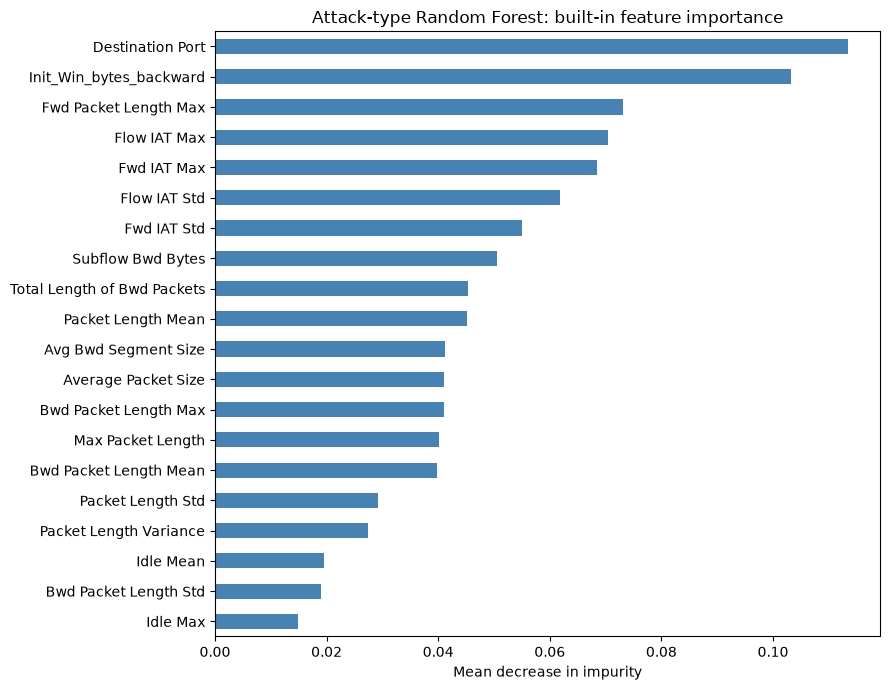

In [3]:
def show_tree_importance(model, title):
    importance = pd.Series(
        model.feature_importances_, index=features, name='importance'
    ).sort_values(ascending=False)
    print(title)
    display(importance.to_frame().round(5))

    importance.sort_values().plot.barh(figsize=(9, 7), color='steelblue')
    plt.title(title)
    plt.xlabel('Mean decrease in impurity')
    plt.tight_layout()
    plt.show()
    return importance

binary_tree_importance = show_tree_importance(
    binary_model, 'Binary Random Forest: built-in feature importance'
)
attack_tree_importance = show_tree_importance(
    attack_model, 'Attack-type Random Forest: built-in feature importance'
)

## 2. Permutation importance

A feature is important when shuffling it reduces the model's F1 score. A fixed sample keeps this optional analysis fast and reproducible.

Binary model: permutation importance


,feature,mean_score_decrease,standard_deviation
9,Destination Port,0.20327,0.01240
12,Flow IAT Max,0.06857,0.00184
18,Init_Win_bytes_backward,0.05799,0.00486
13,Subflow Bwd Bytes,0.00739,0.00114
19,Idle Mean,0.00634,0.00029
15,Flow IAT Std,0.00596,0.00073
3,Average Packet Size,0.00519,0.00115
10,Fwd IAT Std,0.00511,0.00203
14,Total Length of Bwd Packets,0.00423,0.00098
11,Fwd IAT Max,0.00324,0.00149


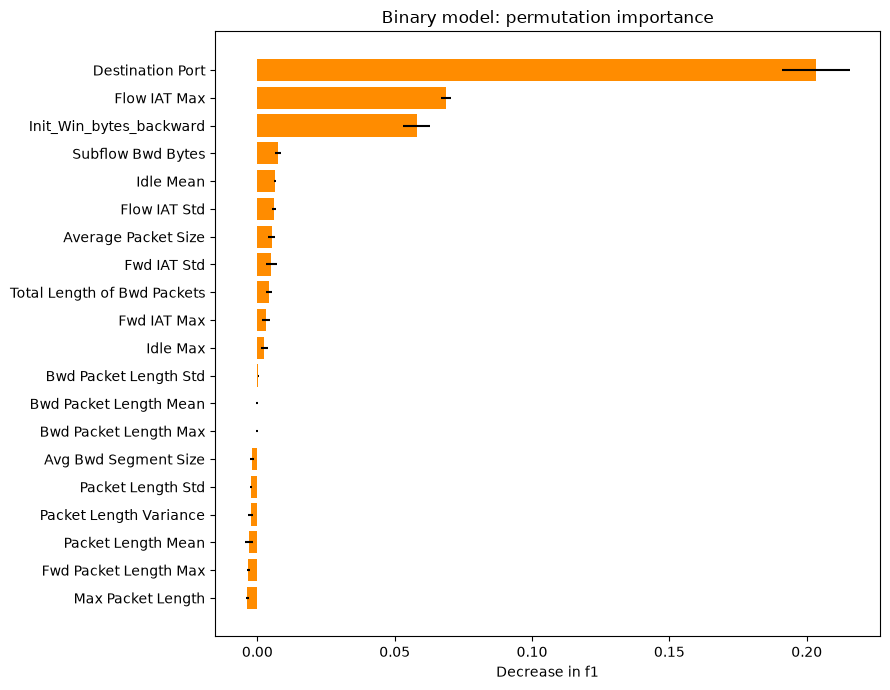

Attack-type model: permutation importance


,feature,mean_score_decrease,standard_deviation
9,Destination Port,0.13720,0.00163
18,Init_Win_bytes_backward,0.09214,0.01187
10,Fwd IAT Std,0.01512,0.00562
12,Flow IAT Max,0.01223,0.00715
15,Flow IAT Std,0.00938,0.00993
11,Fwd IAT Max,0.00325,0.00758
5,Packet Length Mean,0.00157,0.00066
0,Packet Length Variance,0.00070,0.00164
1,Packet Length Std,0.00068,0.00164
16,Idle Max,0.00033,0.00247


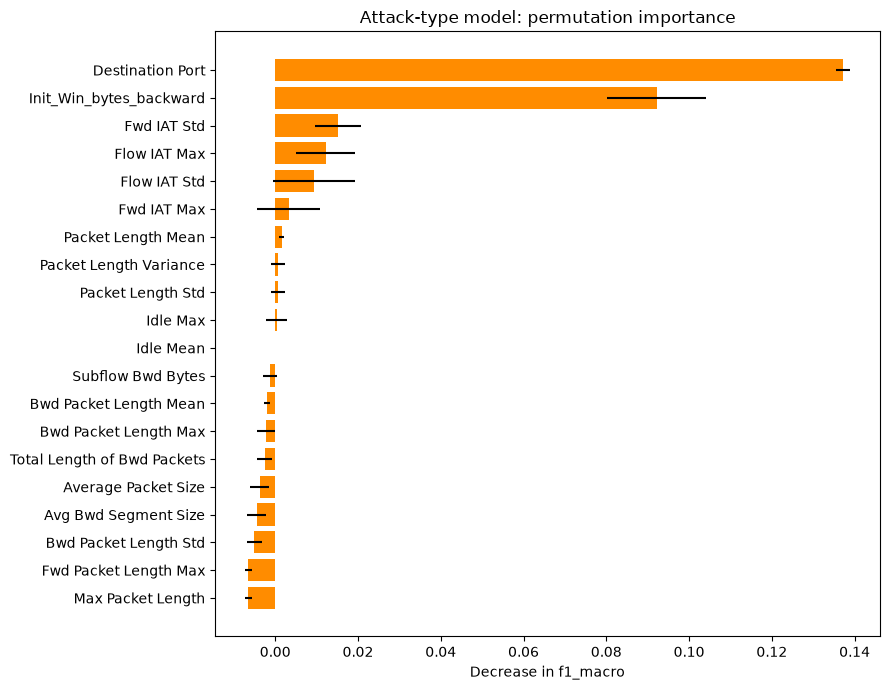

In [4]:
def show_permutation_importance(model, x, y, scoring, title):
    result = permutation_importance(
        model, x, y, scoring=scoring, n_repeats=3,
        random_state=RANDOM_STATE, n_jobs=1,
    )
    importance = pd.DataFrame({
        'feature': features,
        'mean_score_decrease': result.importances_mean,
        'standard_deviation': result.importances_std,
    }).sort_values('mean_score_decrease', ascending=False)

    print(title)
    display(importance.round(5))
    plot_data = importance.sort_values('mean_score_decrease')
    plt.figure(figsize=(9, 7))
    plt.barh(
        plot_data['feature'], plot_data['mean_score_decrease'],
        xerr=plot_data['standard_deviation'], color='darkorange',
    )
    plt.xlabel(f'Decrease in {scoring}')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return importance

binary_sample = test.sample(5000, random_state=RANDOM_STATE)
binary_permutation = show_permutation_importance(
    binary_model, binary_sample[features], binary_sample['is_attack'],
    scoring='f1', title='Binary model: permutation importance',
)

attack_rows = test[test['is_attack'] == 1]
attack_sample = attack_rows.sample(5000, random_state=RANDOM_STATE)
attack_permutation = show_permutation_importance(
    attack_model, attack_sample[features], attack_sample['attack_label'],
    scoring='f1_macro', title='Attack-type model: permutation importance',
)

## 3. Global SHAP explanation for attack detection

The beeswarm plot shows both importance and direction. Red means a high feature value, blue means a low value, and the horizontal position shows whether it pushes the model toward or away from **attack**.

Binary SHAP dimensions: (1000, 20, 2)
(rows, features, classes)


,mean_absolute_shap
Destination Port,0.060327
Init_Win_bytes_backward,0.044874
Bwd Packet Length Std,0.044675
Average Packet Size,0.043292
Subflow Bwd Bytes,0.036748
Packet Length Variance,0.034292
Bwd Packet Length Mean,0.034150
Total Length of Bwd Packets,0.033010
Avg Bwd Segment Size,0.032348
Packet Length Mean,0.031684


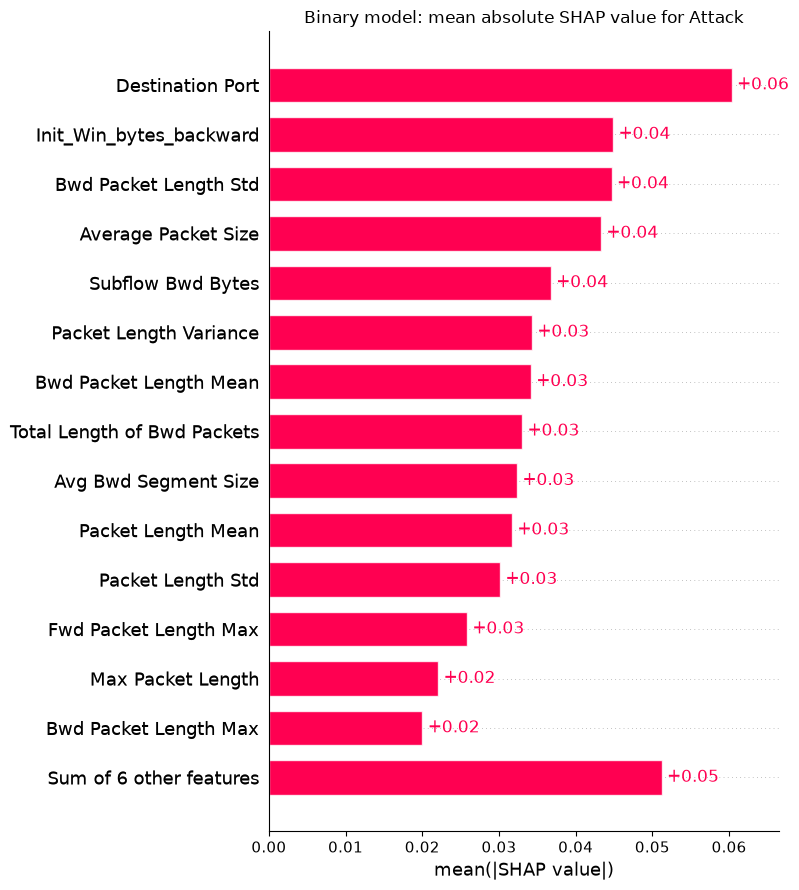

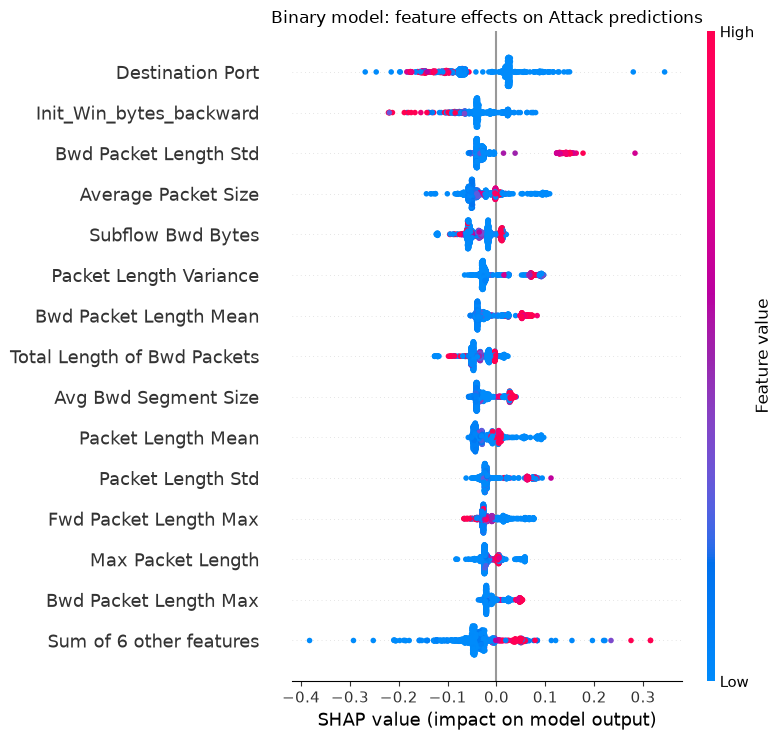

In [5]:
binary_shap_sample = test.sample(1000, random_state=RANDOM_STATE)[features]
binary_explainer = shap.TreeExplainer(binary_model)
binary_explanation = binary_explainer(binary_shap_sample)
attack_class_index = list(binary_model.classes_).index(1)
binary_attack_shap = binary_explanation[:, :, attack_class_index]

print(f'Binary SHAP dimensions: {binary_explanation.values.shape}')
print('(rows, features, classes)')
binary_shap_importance = pd.Series(
    np.abs(binary_attack_shap.values).mean(axis=0),
    index=features, name='mean_absolute_shap',
).sort_values(ascending=False)
display(binary_shap_importance.to_frame().round(6))

shap.plots.bar(binary_attack_shap, max_display=15, show=False)
plt.title('Binary model: mean absolute SHAP value for Attack')
plt.tight_layout()
plt.show()

shap.plots.beeswarm(binary_attack_shap, max_display=15, show=False)
plt.title('Binary model: feature effects on Attack predictions')
plt.tight_layout()
plt.show()

## 4. Explain one binary decision

The waterfall begins at the model's average output and shows how each feature moves this flow toward its final attack probability.

Binary decision being explained
  Test row position:   60
  Actual label:        BENIGN
  Actual is_attack:    0
  Predicted is_attack: 1
  Attack probability:  0.581864


,feature value
Packet Length Variance,-0.3143
Packet Length Std,-0.4997
Bwd Packet Length Std,-0.4274
Average Packet Size,-0.6151
Avg Bwd Segment Size,-0.5386
Packet Length Mean,-0.5991
Bwd Packet Length Max,-0.4783
Bwd Packet Length Mean,-0.5386
Max Packet Length,-0.5014
Destination Port,-0.4527


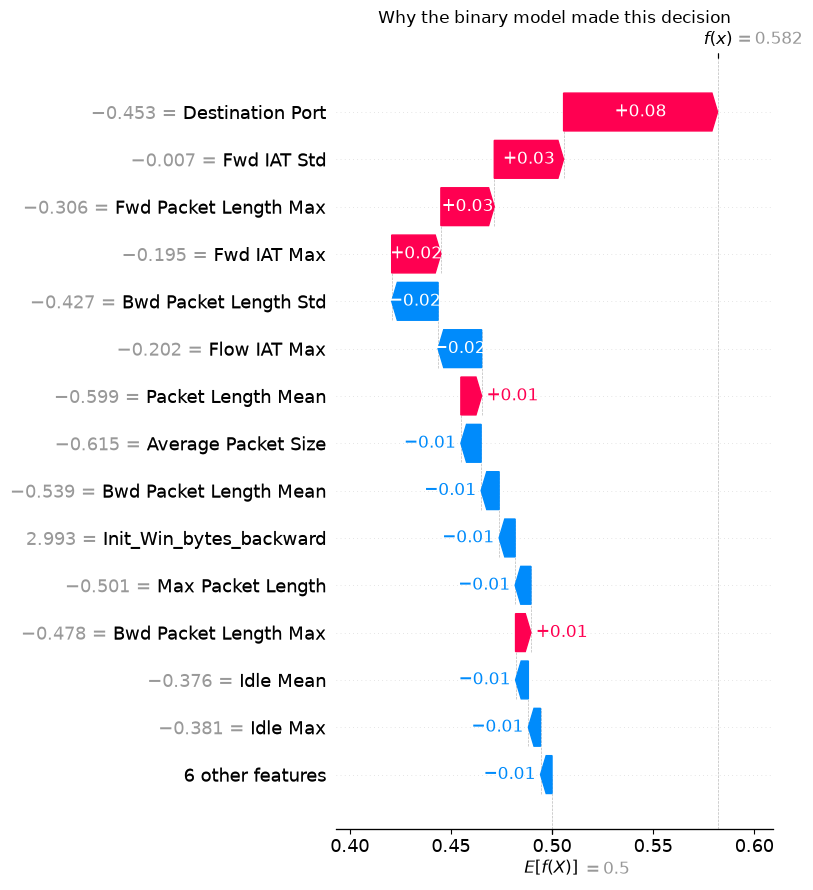

In [6]:
binary_probabilities = binary_model.predict_proba(test[features])[:, attack_class_index]
binary_predictions = (binary_probabilities >= 0.5).astype('int8')
binary_errors = np.flatnonzero(binary_predictions != test['is_attack'].to_numpy())
example_position = int(binary_errors[0]) if len(binary_errors) else 0
example_x = test[features].iloc[[example_position]]
example_explanation = binary_explainer(example_x)[:, :, attack_class_index]

print('Binary decision being explained')
print(f'  Test row position:   {example_position}')
print(f"  Actual label:        {test.iloc[example_position]['attack_label']}")
print(f'  Actual is_attack:    {int(test.iloc[example_position].is_attack)}')
print(f'  Predicted is_attack: {int(binary_predictions[example_position])}')
print(f'  Attack probability:  {binary_probabilities[example_position]:.6f}')
display(example_x.transpose().rename(columns={example_x.index[0]: 'feature value'}).round(4))

shap.plots.waterfall(example_explanation[0], max_display=15, show=False)
plt.title('Why the binary model made this decision')
plt.tight_layout()
plt.show()

## 5. Global SHAP explanation for attack types

For multiclass prediction, every feature has a separate SHAP value for each of the 14 attack classes. The table below averages absolute effects across both rows and classes.

Attack-type SHAP dimensions: (1000, 20, 14)
(rows, features, attack classes)


,mean_absolute_shap
Init_Win_bytes_backward,0.019525
Destination Port,0.019036
Fwd Packet Length Max,0.013964
Bwd Packet Length Max,0.012156
Avg Bwd Segment Size,0.011975
Fwd IAT Max,0.009433
Max Packet Length,0.009428
Subflow Bwd Bytes,0.009368
Bwd Packet Length Mean,0.009244
Total Length of Bwd Packets,0.009174


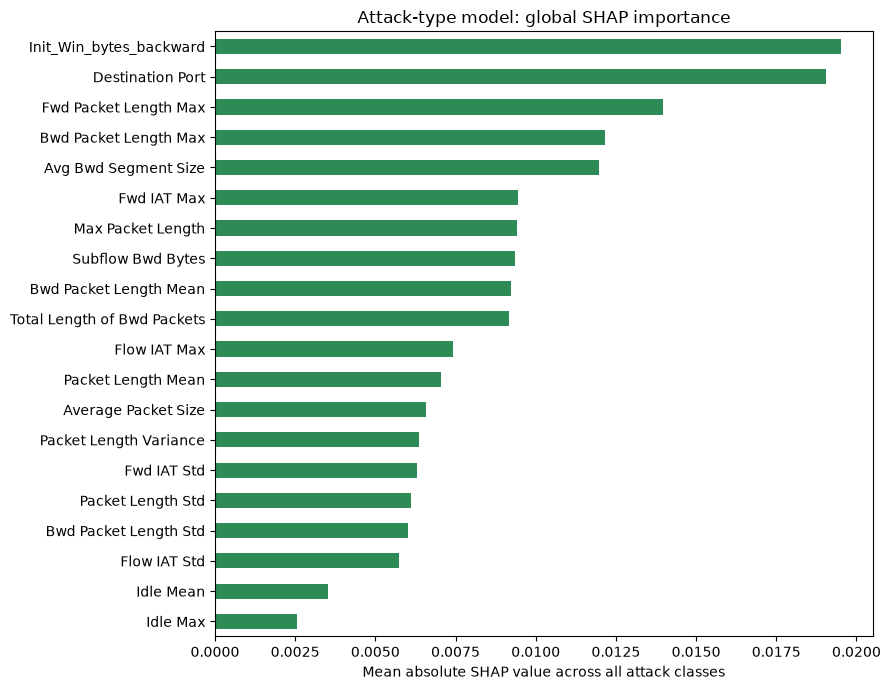

In [7]:
attack_shap_sample = attack_rows.sample(1000, random_state=RANDOM_STATE)[features]
attack_explainer = shap.TreeExplainer(attack_model)
attack_explanation = attack_explainer(attack_shap_sample)

print(f'Attack-type SHAP dimensions: {attack_explanation.values.shape}')
print('(rows, features, attack classes)')
attack_shap_importance = pd.Series(
    np.abs(attack_explanation.values).mean(axis=(0, 2)),
    index=features, name='mean_absolute_shap',
).sort_values(ascending=False)
display(attack_shap_importance.to_frame().round(6))

attack_shap_importance.sort_values().plot.barh(figsize=(9, 7), color='seagreen')
plt.xlabel('Mean absolute SHAP value across all attack classes')
plt.title('Attack-type model: global SHAP importance')
plt.tight_layout()
plt.show()

## 6. Explain one attack-type decision

This selects a misclassified attack when one exists and explains the features that supported the model's predicted class.

Attack-type decision being explained
  Attack row position: 480
  Actual attack:       DoS GoldenEye
  Predicted attack:    DoS Hulk
  Model confidence:    0.883400


,feature value
Packet Length Variance,-0.3143
Packet Length Std,-0.4997
Bwd Packet Length Std,-0.4274
Average Packet Size,-0.6151
Avg Bwd Segment Size,-0.5386
Packet Length Mean,-0.5991
Bwd Packet Length Max,-0.4783
Bwd Packet Length Mean,-0.5386
Max Packet Length,-0.5014
Destination Port,-0.4527


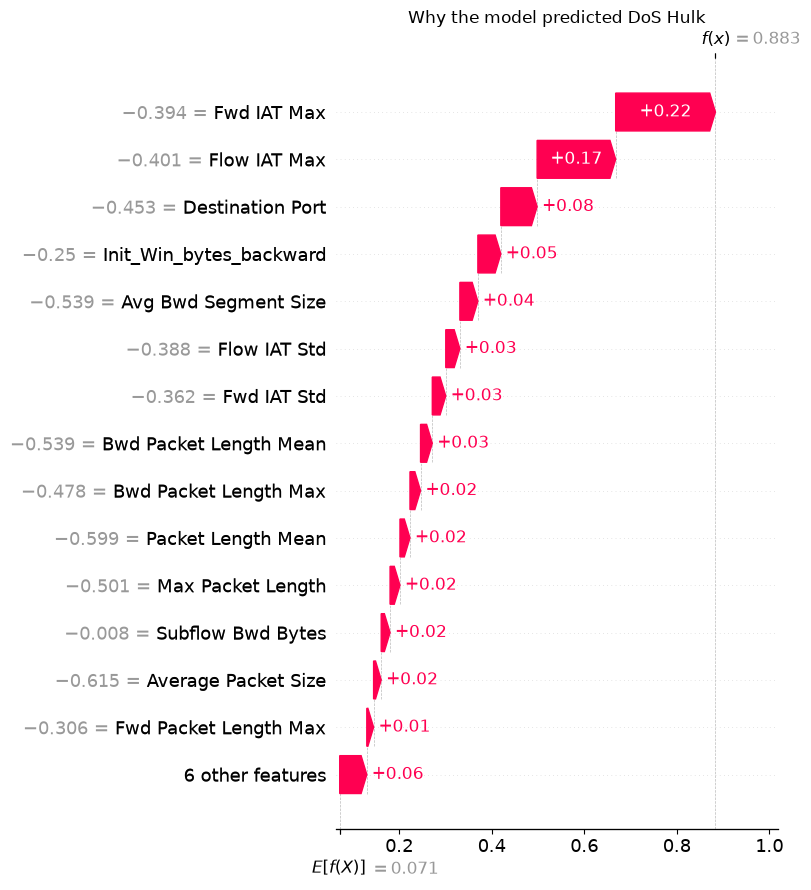

In [8]:
attack_predictions = attack_model.predict(attack_rows[features])
attack_errors = np.flatnonzero(attack_predictions != attack_rows['attack_label'].to_numpy())
attack_position = int(attack_errors[0]) if len(attack_errors) else 0
attack_example_x = attack_rows[features].iloc[[attack_position]]
actual_attack = attack_rows['attack_label'].iloc[attack_position]
predicted_attack = attack_predictions[attack_position]
predicted_class_index = list(attack_model.classes_).index(predicted_attack)
attack_probability = attack_model.predict_proba(attack_example_x)[0, predicted_class_index]
attack_example_explanation = attack_explainer(attack_example_x)[:, :, predicted_class_index]

print('Attack-type decision being explained')
print(f'  Attack row position: {attack_position}')
print(f'  Actual attack:       {actual_attack}')
print(f'  Predicted attack:    {predicted_attack}')
print(f'  Model confidence:    {attack_probability:.6f}')
display(attack_example_x.transpose().rename(columns={attack_example_x.index[0]: 'feature value'}).round(4))

shap.plots.waterfall(attack_example_explanation[0], max_display=15, show=False)
plt.title(f'Why the model predicted {predicted_attack}')
plt.tight_layout()
plt.show()

## How to interpret these explanations

- Agreement between tree importance, permutation importance, and SHAP gives stronger evidence that a feature matters.
- SHAP explains the model's behavior; it does **not** prove that a feature causes an attack.
- Correlated network features can share or exchange importance.
- Explanations for Heartbleed, SQL Injection, and other tiny classes are unstable because very few examples exist.
- For a future neural-network model, use `shap.DeepExplainer` or `shap.GradientExplainer`; `TreeExplainer` is the efficient choice for the current Random Forests.